<a href="https://colab.research.google.com/github/Hatthore/UNIVERSIDAD-QUIMICA-GCOLAB/blob/General/Titulaci%C3%B3n_Amino%C3%A1cidos_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

# 1. Subir archivos (selecciona tus CSV desde el explorador)
uploaded = files.upload()

# 2. Buscar cuáles son de NaOH y cuáles de HCl
df_naoh, df_hcl = None, None

for fname in uploaded.keys():
    lower = fname.lower()
    if "naoh" in lower:
        df_naoh = pd.read_csv(fname)
        print(f"Cargado archivo NaOH: {fname}")
    elif "hcl" in lower:
        df_hcl = pd.read_csv(fname)
        print(f"Cargado archivo HCl: {fname}")

# 3. Verificar que se cargaron
if df_naoh is not None:
    print("\nDatos NaOH (primeras filas):")
    display(df_naoh.head())
else:
    print("\n⚠️ No se encontró archivo de NaOH, revisa el nombre del CSV")

if df_hcl is not None:
    print("\nDatos HCl (primeras filas):")
    display(df_hcl.head())
else:
    print("\n⚠️ No se encontró archivo de HCl, revisa el nombre del CSV")

Saving alanina_hcl_datos (1).csv to alanina_hcl_datos (1).csv
Saving alanina_naoh_datos (1).csv to alanina_naoh_datos (1).csv
Cargado archivo HCl: alanina_hcl_datos (1).csv
Cargado archivo NaOH: alanina_naoh_datos (1).csv

Datos NaOH (primeras filas):


,volumen_mL,pH
0,0.0,6.81
1,0.3,7.29
2,0.6,7.89
3,1.1,8.23
4,1.4,8.41



Datos HCl (primeras filas):


,volumen_mL,pH
0,0.0,6.81
1,0.3,6.18
2,0.6,4.28
3,0.9,3.71
4,1.2,3.47


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la práctica
C_alanina = 0.1      # M
V_alanina_mL = 5.0   # mL
n_alanina_mmol = C_alanina * V_alanina_mL  # mmol
C_titulante = 0.05   # M
valencia = 1         # monoprótico

# Volúmenes teóricos de equivalencia
V_eq_1_mL = n_alanina_mmol / C_titulante   # 10 mL
V_eq_2_mL = 2 * V_eq_1_mL                  # 20 mL

V_eq_1_mL, V_eq_2_mL

(10.0, 20.0)

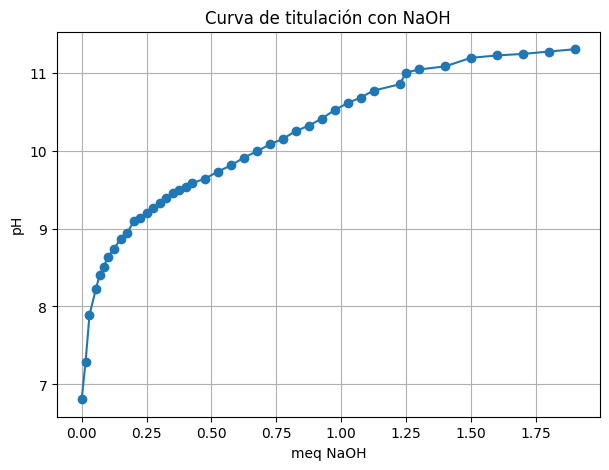

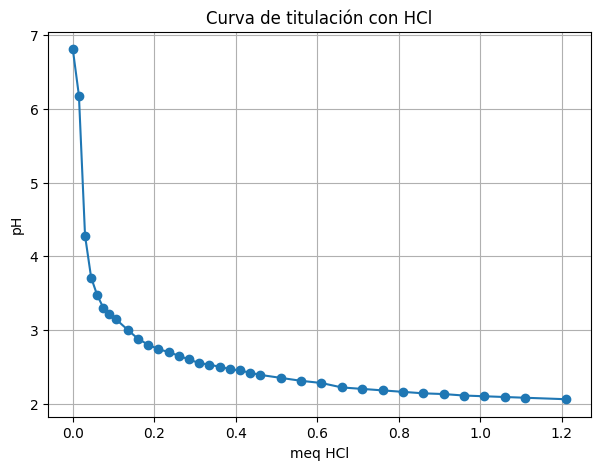

In [4]:
def meq_from_volume(volumen_mL, C_M=C_titulante, z=1):
    return C_M * (volumen_mL / 1000) * 1000 * z  # miliequivalentes

def plot_curve(df, titulo, x_label):
    df = df.copy()
    df["meq"] = meq_from_volume(df["volumen_mL"])
    plt.figure(figsize=(7,5))
    plt.plot(df["meq"], df["pH"], marker="o")
    plt.xlabel(x_label)
    plt.ylabel("pH")
    plt.title(titulo)
    plt.grid(True)
    plt.show()
    return df

df_naoh_proc = plot_curve(df_naoh, "Curva de titulación con NaOH", "meq NaOH")
df_hcl_proc  = plot_curve(df_hcl, "Curva de titulación con HCl", "meq HCl")

In [5]:
def interp_y(x, y, x0):
    return float(np.interp(x0, x, y))

def estimar_pkas(df):
    x = df["volumen_mL"].values
    y = df["pH"].values
    v_he1 = V_eq_1_mL/2
    v_he2 = V_eq_1_mL + V_eq_1_mL/2
    pKa1 = interp_y(x, y, v_he1)
    pKa2 = interp_y(x, y, v_he2)
    return pKa1, pKa2

pKa1_est, pKa2_est = estimar_pkas(df_naoh_proc)
pI_est = (pKa1_est + pKa2_est)/2

print(f"pKa1 estimado = {pKa1_est:.2f}")
print(f"pKa2 estimado = {pKa2_est:.2f}")
print(f"pI estimado   = {pI_est:.2f}")

pKa1 estimado = 9.20
pKa2 estimado = 10.12
pI estimado   = 9.66


In [6]:
pKa1_ref = 2.34
pKa2_ref = 9.69
pI_ref   = (pKa1_ref + pKa2_ref)/2

def error(exp, ref):
    return abs((exp-ref)/ref)*100

print(f"Error pKa1: {error(pKa1_est,pKa1_ref):.2f}%")
print(f"Error pKa2: {error(pKa2_est,pKa2_ref):.2f}%")
print(f"Error pI:   {error(pI_est,pI_ref):.2f}%")


Error pKa1: 293.16%
Error pKa2: 4.39%
Error pI:   60.56%


In [7]:
pH_eval = 7.0

def frac_A_minus(pH, pKa):  # carboxilo
    return 1 / (1 + 10**(pKa - pH))

def frac_BH_plus(pH, pKa):  # amonio
    return 1 / (1 + 10**(pH - pKa))

f_carboxilo = frac_A_minus(pH_eval, pKa1_ref)
f_ammonio   = frac_BH_plus(pH_eval, pKa2_ref)

print(f"A pH 7:")
print(f"Carboxilo deprotonado (A-): {f_carboxilo:.3f}")
print(f"Carboxilo protonado (HA):   {1-f_carboxilo:.3f}")
print(f"Amonio protonado (BH+):     {f_ammonio:.3f}")
print(f"Amina libre (B):            {1-f_ammonio:.3f}")

A pH 7:
Carboxilo deprotonado (A-): 1.000
Carboxilo protonado (HA):   0.000
Amonio protonado (BH+):     0.998
Amina libre (B):            0.002


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros del ensayo
C_alanina = 0.1
V_alanina_mL = 5.0
n_alanina_mmol = C_alanina * V_alanina_mL  # 0.5 mmol
C_titulante = 0.05
Veq_teor = n_alanina_mmol / C_titulante    # 10 mL por equivalencia

# ---------- 1) pKa por "media equivalencia teórica" (robusto y simple) ----------
def interp_y(x, y, x0):
    return float(np.interp(x0, x, y))

# pKa1 desde HCl a 5 mL (mitad de la 1ª equivalencia hacia ácido)
x_hcl = df_hcl["volumen_mL"].values
y_hcl = df_hcl["pH"].values
pKa1_exp = interp_y(x_hcl, y_hcl, 0.5*Veq_teor)

# pKa2 desde NaOH a 15 mL (1.5 equivalencias hacia básico)
x_na = df_naoh["volumen_mL"].values
y_na = df_naoh["pH"].values
pKa2_exp = interp_y(x_na, y_na, Veq_teor + 0.5*Veq_teor)

pI_exp = 0.5*(pKa1_exp + pKa2_exp)

# ---------- 2) (Opcional) pKa por picos de derivada (si tus equivalencias no fueron exactamente 10 mL) ----------
def eq_by_derivative(vol_mL, pH, n_peaks=2):
    vol = np.asarray(vol_mL, float)
    ph  = np.asarray(pH, float)
    dph = np.gradient(ph, vol)
    # Tomar los picos más grandes (en valor absoluto) separados
    idx_sorted = np.argsort(-np.abs(dph))
    peaks = []
    for i in idx_sorted:
        if not peaks or all(abs(vol[i]-vol[j])>0.8 for j in peaks):  # separa picos cercanos
            peaks.append(i)
        if len(peaks)>=n_peaks:
            break
    peaks = sorted(peaks, key=lambda k: vol[k])
    return vol[peaks]

# 2a) Pico de equivalencia del lado ácido (HCl) ≈ 1ª eq (usar si sospechas deriva)
Veq1_est = eq_by_derivative(df_hcl["volumen_mL"], df_hcl["pH"], n_peaks=1)[0]
# 2b) Pico de equivalencia del lado básico (NaOH) ≈ 2ª eq (usar si sospechas deriva)
Veq2_est = eq_by_derivative(df_naoh["volumen_mL"], df_naoh["pH"], n_peaks=1)[0] + Veq_teor  # relativo al 0 mL de NaOH

# pKa alternativos usando medias equivalencias estimadas por derivada
pKa1_alt = interp_y(x_hcl, y_hcl, 0.5*Veq1_est)
pKa2_alt = interp_y(x_na,  y_na,  (Veq2_est - Veq_teor) - 0.5*(Veq2_est - Veq_teor) + Veq_teor )  # = Veq_teor + 0.5*Veq_teor si Veq2_est≈2*Veq_teor

# ---------- 3) Comparación con literatura ----------
pKa1_ref, pKa2_ref = 2.34, 9.69
pI_ref = 0.5*(pKa1_ref + pKa2_ref)

def err(exp, ref):
    return abs((exp-ref)/ref)*100

print("=== pKa/pI (método media equivalencia teórica) ===")
print(f"pKa1_exp = {pKa1_exp:.2f}  (error {err(pKa1_exp,pKa1_ref):.1f}%)")
print(f"pKa2_exp = {pKa2_exp:.2f}  (error {err(pKa2_exp,pKa2_ref):.1f}%)")
print(f"pI_exp   = {pI_exp:.2f}    (error {err(pI_exp,pI_ref):.1f}%)\n")

print("=== pKa (opcional) por derivada (si tus V_eq no fueron 10 mL exactos) ===")
print(f"Veq1_est (HCl) ≈ {Veq1_est:.2f} mL, pKa1_alt ≈ {pKa1_alt:.2f}")
print(f"Veq2_est (NaOH)≈ {Veq2_est:.2f} mL (desde 0 total), pKa2_alt ≈ {pKa2_alt:.2f}")



=== pKa/pI (método media equivalencia teórica) ===
pKa1_exp = 2.67  (error 14.1%)
pKa2_exp = 10.12  (error 4.4%)
pI_exp   = 6.39    (error 6.3%)

=== pKa (opcional) por derivada (si tus V_eq no fueron 10 mL exactos) ===
Veq1_est (HCl) ≈ 0.30 mL, pKa1_alt ≈ 6.49
Veq2_est (NaOH)≈ 10.30 mL (desde 0 total), pKa2_alt ≈ 9.70


In [10]:
pH = 7.0

# Usa los pKa EXPERIMENTALES ya corregidos:
# pKa1_exp  (desde HCl a 5 mL aprox.)
# pKa2_exp  (desde NaOH a 15 mL aprox.)

frac_carboxilo_Am = 1/(1+10**(pKa1_exp - pH))
frac_carboxilo_HA  = 1 - frac_carboxilo_Am

frac_amonio_BH = 1/(1+10**(pH - pKa2_exp))
frac_amina_B   = 1 - frac_amonio_BH

print(f"Carboxilo A- : {frac_carboxilo_Am:.6f}")
print(f"Carboxilo HA : {frac_carboxilo_HA:.6f}")
print(f"Amonio BH+   : {frac_amonio_BH:.6f}")
print(f"Amina B      : {frac_amina_B:.6f}")

Carboxilo A- : 0.999953
Carboxilo HA : 0.000047
Amonio BH+   : 0.999233
Amina B      : 0.000767
